# Feature Scaling

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42
rng = np.random.default_rng(seed=RANDOM_STATE)

## 1 Introduction

### 1.1 Introduction

#### What is Feature Scaling?

Feature scaling is a data preprocessing technique used to transform the numerical features of a dataset into a shared, consistent scale or range.

#### Need for Feature Scaling

1. Features in the dataset will be of different units and/or ranges.
2. Features with different scales impact model learning weights.
3. Smaller values of $x$ helps Gradient descent converge faster.
4. To solve this problem we need to re-scale all features.

#### Types of Scaling

Feature Scaling Techniques:

1. Min-Max Scaling
2. Standardization
3. Robust Scaling
4. Max-Absolute Scaling
5. Unit-vector normalization

## 2 Min-Max Scaling

### 2.1 Introduction

#### Formula

$$
\large
\frac{X_i\;-\;X_{min}}{X_{max}\;-\;X_{min}}
$$

#### Properties

- Resulting scaled values are guaranteed to be in the range between $0$ and $1$.
- When $X_i$ in minimum the resulting value will be zero.
- When $X_i$ in maximum the resulting value will be one.
- Faster convergence when using Gradient Descent because $x$ values are very small b/w $0$ and $1$.

#### API

In [3]:
from sklearn.preprocessing import MinMaxScaler

### 2.2 Examples

In [4]:
mm_scaler = MinMaxScaler()
X = np.array([10, 99, 76, 26, 83, 0, 51, 14, 1]).reshape(-1, 1)
mm_scaler.fit_transform(X)

array([[0.1010101 ],
       [1.        ],
       [0.76767677],
       [0.26262626],
       [0.83838384],
       [0.        ],
       [0.51515152],
       [0.14141414],
       [0.01010101]])

## 3 Standardization

### 3.1 Introduction

#### Formula

$$
\large
\frac{X_i\;-\;\mu}{\sigma}
$$

#### Properties

- Scales data to a **Normal Distribution**.
- Resulting distribution has zero $\mu$ and one $\sigma$
- Majority of data i.e., ~99.7% data lies between -3 and +3 (not guaranteed) when no outliers.
- When there are outliers the range can be much larger for example between -10 and 10.

#### API

In [5]:
from sklearn.preprocessing import StandardScaler

### 3.2 Examples

#### Example #1

In [6]:
std_scaler = StandardScaler()
X = np.array([5, 2, 3, 1, 6, 8, 9, 0, 7, 4]).reshape(-1, 1)
Xs = std_scaler.fit_transform(X)
Xs

array([[ 0.17407766],
       [-0.87038828],
       [-0.52223297],
       [-1.21854359],
       [ 0.52223297],
       [ 1.21854359],
       [ 1.5666989 ],
       [-1.5666989 ],
       [ 0.87038828],
       [-0.17407766]])

#### Example #2

In [7]:
X = rng.integers(low=1, high=501, size=100)
pd.Series(X).describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
0,100.0,263.85,136.403025,22.0,161.5,260.5,381.75,488.0


Original Range of X (without outliers): [3, 497]

In [8]:
Xs = std_scaler.fit_transform(X.reshape(-1, 1))  # X scaled
pd.Series(Xs.flatten()).describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
0,100.0,-1.576517e-16,1.005038,-1.781987,-0.75413,-0.024683,0.868705,1.651571


New Range of X scaled (without outliers): [-1.78, 1.65]

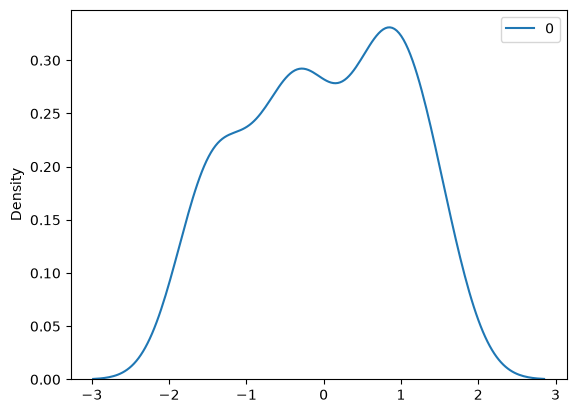

In [9]:
sns.kdeplot(Xs)
plt.show()

##### Add outliers

In [10]:
o1 = rng.integers(low=-10_000, high=-99, size=5)
o1

array([-1756, -8021, -2031, -9928, -2111])

Expected output: `array([-1756, -8021, -2031, -9928, -2111])` for current chosen RANDOM_STATE.

In [11]:
o2 = rng.integers(low=9_000, high=10_000, size=5)
o2

array([9786, 9780, 9664, 9471, 9705])

Expected output: `array([9786, 9780, 9664, 9471, 9705])` for current chosen RANDOM_STATE.

In [12]:
X = np.concatenate((X, o1, o2), axis=0)
rng.shuffle(X)
pd.Series(X).describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
0,110.0,463.127273,2401.204782,-9928.0,140.5,260.5,389.25,9786.0


Original Range of X (with outliers): [-9928, 9786]

In [13]:
Xs = std_scaler.fit_transform(X.reshape(-1, 1))  # X scaled
pd.Series(Xs.flatten()).describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
0,110.0,-3.418982e-17,1.004577,-4.347269,-0.134976,-0.084772,-0.030908,3.900351


New Range of X scaled (with outliers): [-4.35, 3.9]

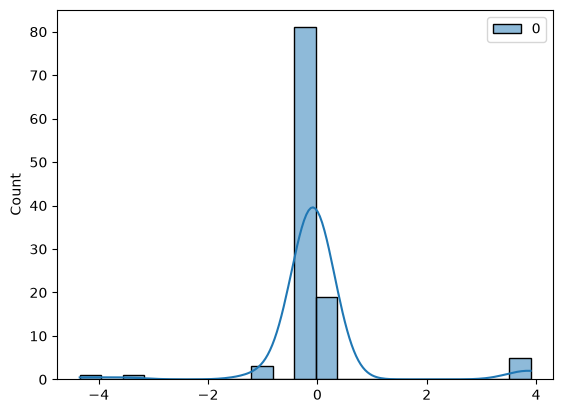

In [14]:
sns.histplot(Xs, kde=True)
plt.show()

## 4 Robust Scaling

### 4.1 Introduction

#### Formula

$$
\large
\frac{X_i\;-\;\eta}{\mathrm{IQR}\;}
$$

#### Properties

#### API

### 4.2 Examples

#### Example #1

## 5 Max-Absolute Scaling

### 5.1 Introduction

#### Formula

$$
\large
\frac{X_i}{\vert{X_{max}}\vert}
$$

#### Properties

#### API

### 5.2 Examples

#### Example #1